In [4]:
# 4.1
x = [1,2,3,10]
y = [10, 20, 30, 40]

# adding x and y with list comprehension with zip()
z = [x + y for x,y in zip(x,y)]
(print(z))

# adding x and y by using map()
def addition(x, y):
    return x+y
z = list(map(addition, x, y))
print(z)

[11, 22, 33, 50]
[11, 22, 33, 50]


In [23]:
# 4.3
import numpy as np
print("Welcome to Rock-Paper-Scissors \nType 'R' for Rock, 'P' for Paper or 'S' for Scissors")

def play_game():
    '''Determines the winner based on the user choice and computer choice'''
    choices = ['R', 'P', 'S']
    user_choice = input('R, P or S: ')
    computer_choice = np.random.choice(choices)
    print(f"You: {user_choice} against computer: {computer_choice}")
    if user_choice==computer_choice:
        return 'No winner'
    elif choices.index(user_choice) == (choices.index(computer_choice) - 1):
        return 'Computer won'
    else:
        return 'You won :)'

print(play_game())
    

Welcome to Rock-Paper-Scissors 
Type 'R' for Rock, 'P' for Paper or 'S' for Scissors


R, P or S:  P


You: P against computer: S
Computer won


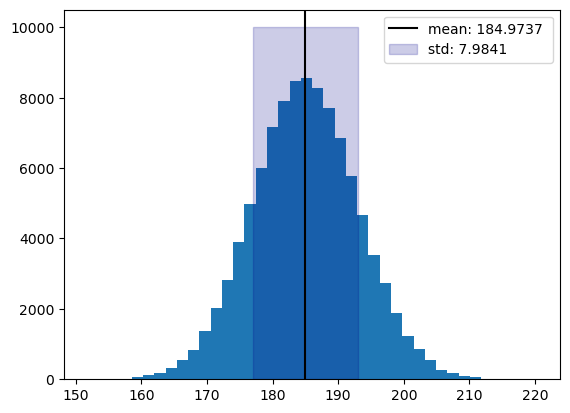

Probability that height is smaller or equal to 170 cm: 0.03039636176526137
Probability that height is between the standard deviation range: 0.6817233337951376


In [8]:
# 4.4
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

humans = np.random.normal(185, 8, 100000)
mean = humans.mean()
std = humans.std()

# Create the histogram
plt.hist(humans, 40)

# Create a vertical line at the mean
plt.axvline(mean, color='black', label=f"mean: {mean:.4f} ")

# Create a shading area for the std range from the mean
x = [mean-std, mean+std, mean+std, mean-std]
y = [0, 0, 10000, 10000]
plt.fill(x, y, color='darkblue', alpha=0.2, label=f"std: {std:.4f}")
plt.legend()
plt.show()

def calc_prob1(h):
    '''Returns probability of any values X that 
    are smaller than and equal to the specified height h'''
    cdf = norm.cdf(h, 185, 8)
    return cdf

def calc_prob2(mean, std):
    '''Returns probability of any values X that 
    are withing the standard deviation range'''
    cdf = norm.cdf(mean+std, 185, 8) - norm.cdf(mean-std, 185, 8)
    return cdf


print(f'Probability that height is smaller or equal to 170 cm: {calc_prob1(170)}')
print(f'Probability that height is between the standard deviation range: {calc_prob2(mean, std)}')

In [45]:
# 4.6
import numpy as np

# User input
userfunc = input('Function: ')
a = input('First boundary a: ')
b = input('Second boundary b: ')

def calc_integral(f, a, b, N=10000):
    '''Calculates integral from input function and input boundaries a and b'''
    a, b = float(a), float(b)
    
    x = np.random.uniform(a,b, N)
    integral = (b-a) * np.sum(eval(f)) / N
    
    return integral

print(f'Calculated integral: {calc_integral(userfunc, a, b)}')
    

Function:  x
First boundary a:  0
Second boundary b:  1


Calculated integral: 0.494421055851639


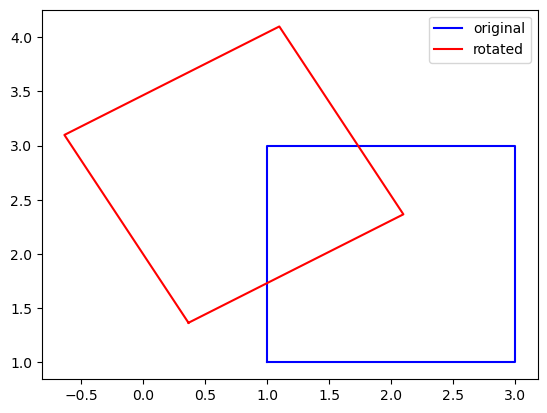

In [2]:
# 4.12
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

theta = radians(30)
rotor = cos(theta) + sin(theta) * 1j
xy = (x + y*1j) * rotor
x_new, y_new = xy.real, xy.imag
plt.plot(x, y, color='blue', label='original')
plt.plot(x_new, y_new, color='red', label='rotated')
plt.legend()
plt.show()

In [6]:
# 4.14
import numpy as np
def funcfilter(func, seq):
    '''Returns filtered function'''
    seq = np.asarray(seq)
    seq = seq[seq > 0]
    return func(seq)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result 1 log10:", result)
result2 = funcfilter(np.log10, 100)
print("Result 2 log10:", result2)   

Result 1 log10: [1. 2.]
Result 2 log10: [2.]


In [133]:
# 4.16
from astropy.cosmology import Planck18
from scipy import integrate

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0
print(H0, Planck18.H0.unit)

def calc_H(z):
    '''Calculates H(z) from input value z'''
    H = H0*(Om0*(1+z)**3 +Ode0)**0.5
    return H

def F(z):
    H = calc_H(z)
    y = 1/((1+z)*H)
    return y
 
area = integrate.quad(F, 0, 2)
print(area)
integral_result = area[0]*3.086e19/3600/24/365.25/1e9
print(f'The lookback time for z=2 is {integral_result} Gyr')

67.66 km / (Mpc s)
(0.010765276277273951, 1.7097849663277088e-15)
The lookback time for z=2 is 10.527303277710413 Gyr


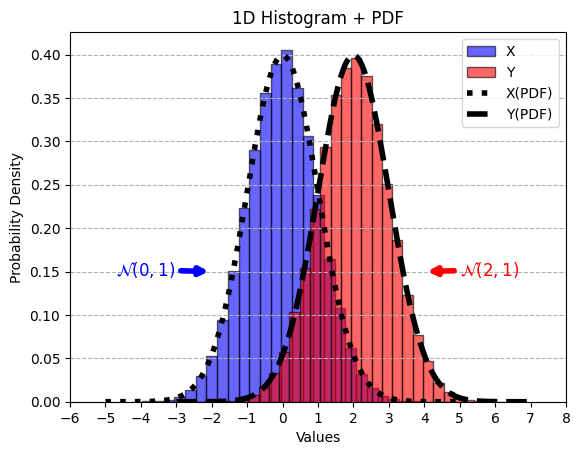

In [119]:
# 4.21
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# Plot histograms
fig, frame = plt.subplots(1, 1)
frame.hist(X, bins=30, color='blue', edgecolor='black', alpha=0.6, label='X', density=True)
frame.hist(Y, bins=30, color='red', edgecolor='black', alpha=0.6, label='Y', density=True)

# Plot PDF(X)
x_values = np.linspace(-5, 5, 1000)
pdf_x = norm.pdf(x_values, loc=0, scale=1)
frame.plot(x_values, pdf_x, color='black', linestyle='dotted', linewidth=4, markevery=12, label='X(PDF)')
    
# Plot PDF(Y)
y_values = np.linspace(-3, 7, 1000)
pdf_y = norm.pdf(y_values,loc=2, scale=1)
frame.plot(y_values, pdf_y, color='black', linestyle='--', linewidth=4, label='Y(PDF)')

# Add arrow annotation for the histograms
frame.annotate(
    r'$\mathcal{N}(0, 1)$',
    xy=(-2, 0.15),
    xytext=(-4.7, 0.145),
    fontsize=12,
    color='blue',
    arrowprops=dict(arrowstyle='-|>', color='blue', linewidth=4)
)

frame.annotate(
    r'$\mathcal{N}(2, 1)$',
    xy=(4, 0.15),       # arrow tip at y=0.15
    xytext=(5, 0.145), 
    fontsize=12,
    color='red',
    arrowprops=dict(arrowstyle='-|>', color='red', linewidth=4)
)

frame.set_xlabel("Values")
frame.set_ylabel("Probability Density")
frame.set_title("1D Histogram + PDF")
plt.grid(axis='y', linestyle='--')
frame.legend()
frame.set_xticks(np.arange(-6, 9, 1))
plt.show()

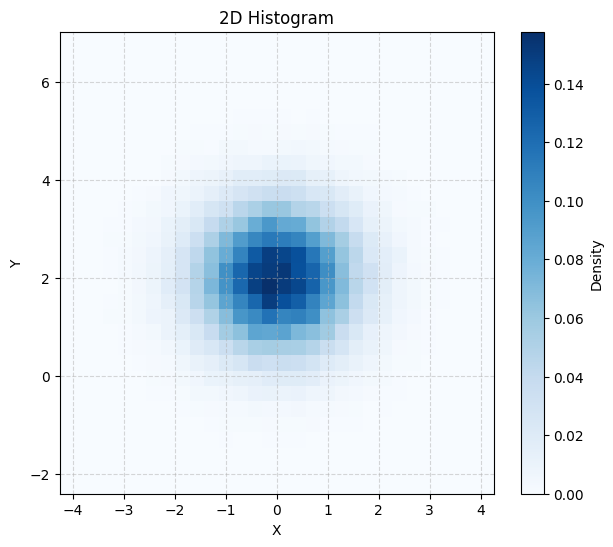

In [135]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

# Generate data
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

# Create 2D histogram
fig, ax = plt.subplots(figsize=(7, 6))
hist = ax.hist2d(X, Y, bins=30, density=True, cmap='Blues')

ax.grid(linestyle='--', alpha=0.5)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('2D Histogram')

plt.colorbar(hist[3], ax=ax, label='Density')  # add color bar
plt.show()

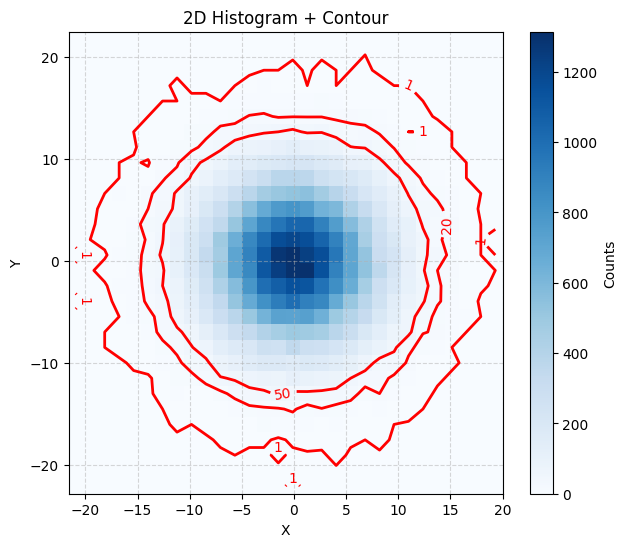

In [131]:
import matplotlib.pyplot as plt
import numpy as np

# Generate data
X = np.random.normal(0, 5, 100000)
Y = np.random.normal(0, 5, 100000)

# Create 2D histogram with counts (not density)
fig, ax = plt.subplots(figsize=(7, 6))
counts, xedges, yedges, im = ax.hist2d(X, Y, bins=30, density=False, cmap='Blues')

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('2D Histogram + Contour')

# Colorbar with counts scale
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Counts')

# Calculate contour levels (choose levels meaningful to counts)
levels = [1, 20, 50]

# Compute the bin centers from edges for contour plotting
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
Xc, Yc = np.meshgrid(xcenters, ycenters)

# Plot contour with counts levels
contours = ax.contour(Xc, Yc, counts.T, levels=levels, colors='red', linewidths=2)
ax.clabel(contours, inline=True, fontsize=10, fmt='%d')

plt.show()